#### 0. Configuracion Inicial

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

df = pd.read_csv('docs/product_activity.csv') # 

#### 1. - Exploracion Inicial

##### 1.1 - Vista general del DataSet

In [24]:
print("Head")
display(df.head())
print("\nInfo")
df.info()
print("\nDescribe")
df.describe()

Head


,user_id,created_at,country,plan_type,user_age,post_id,post_category,post_created_at,votes_received,user_total_posts,days_since_signup,device_type
0,U01988,2025-02-18T02:07:44,PY,pro,26.0,P0008515,sport,2025-05-07T20:55:28,7,16,78,mobile
1,U00236,2025-06-22T07:49:10,BR,free,27.0,P0001023,tech,2025-09-13T20:31:06,1,9,83,web
2,U00791,2024-02-12T02:45:45,CL,free,28.0,P0003405,tech,2024-02-14T05:17:48,11,2,2,mobile
3,U01522,2024-09-22T07:06:50,US,free,16.0,P0006524,finance,2024-09-24T07:51:34,5,2,2,web
4,U01092,2025-07-18T02:27:52,PY,free,NaN,P0004665,education,2025-07-24T04:56:56,7,2,6,mobile



Info
<class 'pandas.DataFrame'>
RangeIndex: 8782 entries, 0 to 8781
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            8782 non-null   str    
 1   created_at         8782 non-null   str    
 2   country            8782 non-null   str    
 3   plan_type          8782 non-null   str    
 4   user_age           8028 non-null   float64
 5   post_id            8782 non-null   str    
 6   post_category      8782 non-null   str    
 7   post_created_at    8782 non-null   str    
 8   votes_received     8782 non-null   int64  
 9   user_total_posts   8782 non-null   int64  
 10  days_since_signup  8782 non-null   int64  
 11  device_type        8782 non-null   str    
dtypes: float64(1), int64(3), str(8)
memory usage: 823.4 KB

Describe


,user_age,votes_received,user_total_posts,days_since_signup
count,8028.000000,8782.000000,8782.000000,8782.000000
mean,27.902591,6.918356,8.324186,29.479390
std,7.547052,5.127311,6.754906,36.819928
min,16.000000,0.000000,1.000000,0.000000
25%,22.000000,3.000000,4.000000,5.000000
50%,28.000000,6.000000,6.000000,17.000000
75%,33.000000,9.000000,11.000000,40.000000
max,58.000000,74.000000,39.000000,404.000000


#### 1.2 - Conteo de nulos y duplicados

In [25]:
# Contar nulos por columnas
print(f"Nulos por Columna:\n {df.isnull().sum()}")

#Contar filas duplicadas exactas
print(f"\nFilas Duplicadas:\n {df.duplicated().sum()}")

Nulos por Columna:
 user_id                0
created_at             0
country                0
plan_type              0
user_age             754
post_id                0
post_category          0
post_created_at        0
votes_received         0
user_total_posts       0
days_since_signup      0
device_type            0
dtype: int64

Filas Duplicadas:
 172


##### 1.3 - Valores únicos y frecuencias

In [26]:
# Para cada columna categorica, ver que valores existen
print(df["plan_type"].value_counts())
print(f"\n {df["post_category"].value_counts()}")
print(f"\n {df["device_type"].value_counts()}")

plan_type
free            5978
pro             1460
enterprise       306
Free             208
 free            197
FREE             196
FreE             189
PRo               46
 pro              44
PRO               44
Pro               38
Pro               35
EnterPrise        13
ENTERPRISE        11
 enterprise        7
Enterprise         7
premium            1
vip                1
enterprise+        1
Name: count, dtype: int64

 post_category
tech           1187
life            913
sports          899
science         753
finance         739
gaming          727
music           614
health          601
education       592
travel          445
 tech            70
Tech             67
TECH             56
tehc             50
Life             46
Finance          44
 sport           42
sciense          42
gamming          40
 life            38
SPORTS           37
 finance         37
LIFE             36
Sports           36
 science         35
sporst           35
Gaming           35
Science  

##### 1.4 - Chequeos lógicos

In [27]:
# Convertir fechas temporalmente para el chequeo
signup = pd.to_datetime(df["created_at"], errors="coerce")
post = pd.to_datetime(df["post_created_at"], errors="coerce")

# Cuantos posts ocurren Antes del signup?
posts_before_signup = (post < signup).sum()
print(f"Posts antes del signup: {posts_before_signup}")

# Days_since_signup es consistente?
dias_calculados = (post - signup).dt.days
dias_originales = df["days_since_signup"]
inconsistentes = (dias_calculados != dias_originales).sum()
print(f"Days_since_signup inconsistentes: {inconsistentes}")

Posts antes del signup: 100
Days_since_signup inconsistentes: 4479


#### 2 - LIMPIEZA BÁSICA CON CRITERIO

##### PASO 2.1 - Eliminar duplicados exactos

In [28]:
duplicados_antes = df.duplicated().sum()
df = df.drop_duplicates()
duplicados_removidos = duplicados_antes

##### 2.2 - Normalización canónica (mapear variantes)

In [ ]:
# Paso previo: poner todo en minusculas y quitar espacios
df["plan_type"] = df["plan_type"].str.strip().str.lower()
df["device_type"] = df["device_type"].str.strip().str.lower()
df["post_category"] = df["post_category"].str.strip().str.lower()

# Definir diccionarios de mapeo para variantes conocidas
# (Los valores exactos dependeran de los que encuentres en 1.3)

mapeo_plan = {
    "free": "free",
    "pro": "pro",
    "enterprise": "enterprise"
}

mapeo_device = {
    "web": "web",
    "mobile": "mobile",
    "desktop": "desktop"
}

mapeo_category = {
    "sport": "sports",
    "sporst": "sports",
    "sp0rts": "sports",
    "tech": "tech",
    "tehc": "tech",
    "life": "life",
    "lfe": "life",
    "gaming": "gaming",
    "gamming": "gaming",
    "music": "music",
    "musc": "music",
    "education": "education",
    "educatoin": "education",
    "health": "health",
    "healt": "health",
    "science": "science",
    "sciense": "science",
    "travel": "travel",
    "trvael": "travel",
    "finance": "finance",
    "finanse": "finance"
}

df["plan_type"] = df["plan_type"].replace(mapeo_plan)
df["device_type"] = df["device_type"].replace(mapeo_device)
df["post_category"] = df["post_category"].replace(mapeo_category)

print(df["plan_type"])
print(df["device_type"])
print(df["post_category"])

0               pro
1              free
2              free
3              free
4              free
           ...     
8777           free
8778     enterprise
8779            pro
8780    enterprise+
8781           free
Name: plan_type, Length: 8610, dtype: str
0        mobile
1           web
2        mobile
3           web
4        mobile
         ...   
8777        web
8778        web
8779     mobile
8780    desktop
8781      phone
Name: device_type, Length: 8610, dtype: str
0          sports
1            tech
2            tech
3         finance
4       education
          ...    
8777       travel
8778      science
8779       sports
8780    education
8781         tech
Name: post_category, Length: 8610, dtype: str


##### 2.3 - Convertir fechas a datetime

In [30]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["post_created_at"] = pd.to_datetime(df["post_created_at"], errors="coerce")

#Reportar fechas no parseables
fechas_nulas_signup = df["created_at"].isna().sum()
fechas_nulas_post = df["post_created_at"].isna().sum()
print(f"Fechas no parseables - signup: {fechas_nulas_signup}")
print(f"Fechas no parseables - post: {fechas_nulas_post}")

Fechas no parseables - signup: 1
Fechas no parseables - post: 1


#### 2.4 - Recálculo obligatorio de days_since_signup

In [ ]:
# Crear la columna recalculada
df["days_since_signup_calc"] = (df["post_created_at"] - df["created_at"]).dt.days

# Comparar con el original
mismatches = (df["days_since_signup"] != df["days_since_signup_calc"]).sum()
print(f"Mismatches en days_since_signaup: {mismatches}")

Msmatches en days_since_signaup: 4401


#### 2.5 - Quarantine (Cuarentena)

In [ ]:
# Identificar filas con errores duros y asignar motivo

# Condicion 1: post_created_at < created_at (post antes del signup)
cond_fecha = df["post_created_at"] < df["created_at"]

# Condicion 2: fechas no parseables (NaT)
cond_nat = df["created_at"].isna() | df["post_created_at"].isna()

# Condicion 3: valores que no estan en el diccionario fijo
planes_validos = ["free", "pro", "enterprise"]
devices_validos = ["web", "mobile", "desktop"]
categorias_validas = ["tech", "life", "sports", "science", "finance", "gaming", "music", "health", "education", "travel"]

cond_plan = ~df["plan_type"].isin(planes_validos)
cond_device = ~df["device_type"].isin(devices_validos)
cond_cat = ~df["post_category"].isin(categorias_validas)

# Crear columnas reason_code
df["reason_code"] = ""
df.loc[cond_fecha, "reason_code"] += "post_antes_signup;"
df.loc[cond_nat, "reason_code"] += "fechas_no_parseables;"
df.loc[cond_plan, "reason_code"] += "plan_invalido;"
df.loc[cond_device, "reason_code"] += "device_invalido;"
df.loc[cond_cat, "reason_code"] += "categoria_invalida;"

# Separar: cuarentena vs core
mascara_quarantine = df["reason_code"] != ""
df_quarantine = df[mascara_quarantine].copy()
df_core = df[~mascara_quarantine].copy()

# Limpiar columna temporal
df_core = df_core.drop(columns=["reason_code"])


#### 3 - DATA QUALITY REPORT

In [33]:
filas_raw = len(df)
filas_core = len(df_core)
filas_quarantine = len(df_quarantine)
pct_quarantine = (filas_quarantine / filas_raw) * 100
pct_mismatches = (mismatches / filas_raw) * 100

dqr = pd.DataFrame({
    'Métrica': ['Filas RAW', 'Filas CORE', 'Filas Quarantine', '% Quarantine', 'Duplicados Removidos', '% Mismatches Fechas'],
    'Valor': [filas_raw, filas_core, filas_quarantine, f"{pct_quarantine:.2f}%", duplicados_antes, f"{pct_mismatches:.2f}%"]
})
display(dqr)

,Métrica,Valor
0,Filas RAW,8610
1,Filas CORE,8507
2,Filas Quarantine,103
3,% Quarantine,1.20%
4,Duplicados Removidos,172
5,% Mismatches Fechas,51.11%


#### 4 - MÉTRICAS Y ANÁLISIS

##### 4.1 - Distribuciones (Volumen)

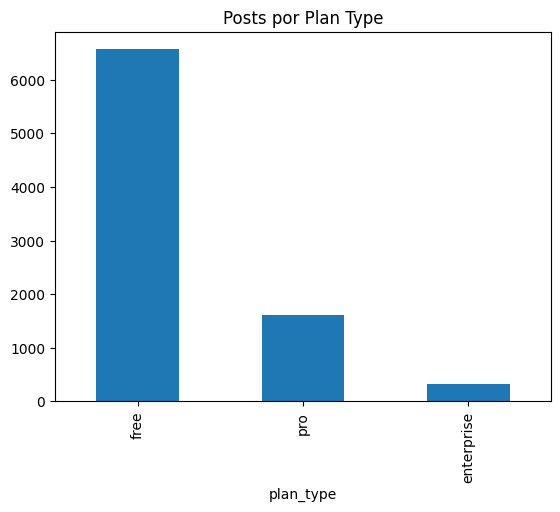

In [34]:
# Usuarios unicos por plan
df_core.groupby("plan_type")["user_id"].nunique()

# Actividad (#posts) por pais, categoria y dispositivo
df_core["country"].value_counts()
df_core["post_category"].value_counts()
df_core["device_type"].value_counts()

# Visualizar con graficos de barras
df_core["plan_type"].value_counts().plot(kind="bar", title="Posts por Plan Type")
plt.show()

##### 4.2 - Engagement (Votos)

In [35]:
# Votos por plan: media y mediana
df_core.groupby("plan_type")["votes_received"].agg(["mean", "median"])

# Votos por pais, categoria y dispositivo: media y mediana
df_core.groupby("country")["votes_received"].agg(["mean", "median"])
df_core.groupby("post_category")["votes_received"].agg(["mean", "median"])
df_core.groupby("device_type")["votes_received"].agg(["mean", "median"])

,mean,median
device_type,,
desktop,7.032702,6.0
mobile,6.828228,6.0
web,6.960656,6.0


##### 4.3 - Promedios e Interpretación

**Interpretación:** La unidad de análisis en este dataset es el *evento* (cada fila es un post). Esto significa que un usuario con muchísimos posts impacta fuertemente en el promedio general (sesgo de heavy users o outliers), ya que sus votos se registran repetidamente, distorsionando la realidad del usuario promedio.

In [ ]:
# Promedio de votos por plan
votos_plan = df_core.groupby("plan_type")["votes_received"].mean()
print(votos_plan)

# Posts promedio por usuario
posts_usuario = df_core.groupby("user_id")["post_id"].count().mean()
print(posts_usuario)

plan_type
enterprise    7.570571
free          6.692706
pro           7.654014
Name: votes_received, dtype: float64
4.266298896690071


##### 4.4 - Evento vs Usuario

**Por qué difieren:** En el nivel *evento*, los usuarios más activos sobrerrepresentan la muestra (si un usuario hace 100 posts, su media pesará 100 veces más). Al calcular por *usuario*, a cada persona se le asigna el mismo peso (1 usuario = 1 promedio), limpiando el efecto que provocan los usuarios extremos.

In [37]:
# Promedio de votos por FILA (nivel evento)
promedio_evento = df_core["votes_received"].mean()
print(promedio_evento)

# Promedio de votos agrupado por USUARIO
promedio_usuario = df_core.groupby("user_id")["votes_received"].mean().mean()
print(promedio_usuario)

6.908663453626425
6.896670958875104


#### 5 - CONCENTRACIÓN Y TEMPORALIDAD

##### 5.1 - Concentración (Top 1%)

In [38]:
# Posts por usuario
posts_usuario = df_core.groupby("user_id")["post_id"].count()
print(posts_usuario)

# Votos por usuario
votos_usuario = df_core.groupby("user_id")["votes_received"].sum()
print(votos_usuario)

# Calcular el umbral del top 1%
umbral_posts = posts_usuario.quantile(0.99)
umbral_votos = votos_usuario.quantile(0.99)

# Filtrar top 1%
top_posts = posts_usuario[posts_usuario >= umbral_posts]
top_votos = votos_usuario[votos_usuario >= umbral_votos]
print(f"Top 1% usuarios por posts: {len(top_posts)}")

# Calcular porcentaje del total
pct_top_posts = (top_posts.sum() / posts_usuario.sum()) * 100
pct_top_votos = (top_votos.sum() / votos_usuario.sum()) * 100
print(f"Top 1% usuarios representan {pct_top_posts:.2f}% de los posts")
print(f"Top 1% usuarios representan {pct_top_votos:.2f}% de los votos")

user_id
U00001     3
U00002     4
U00003     2
U00004     3
U00005     1
          ..
U01997    13
U01998     2
U01999     4
U02000     9
U20008     1
Name: post_id, Length: 1994, dtype: int64
user_id
U00001     15
U00002     37
U00003     12
U00004     14
U00005      4
         ... 
U01997    101
U01998     15
U01999     28
U02000     87
U20008      7
Name: votes_received, Length: 1994, dtype: int64
Top 1% usuarios por posts: 24
Top 1% usuarios representan 6.97% de los posts
Top 1% usuarios representan 6.43% de los votos


##### 5.2 - Tendencia temporal

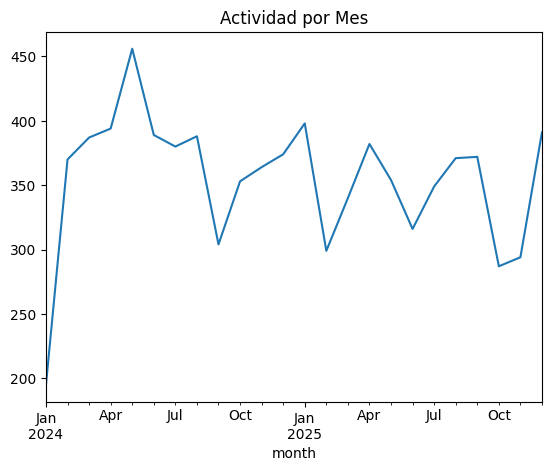

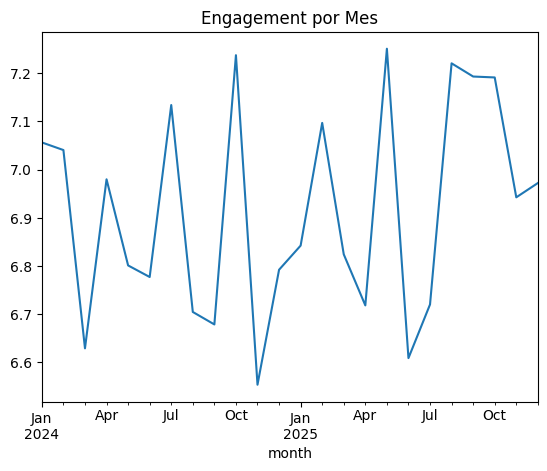

In [39]:
# Crear columna de semana y mes
df_core["week"] = df_core["post_created_at"].dt.isocalendar().week
df_core["month"] = df_core["post_created_at"].dt.to_period("M")

# Actividad por mes
actividad_mes = df_core.groupby("month")["post_id"].count()
actividad_mes.plot(kind="line", title="Actividad por Mes")
plt.show()

# Engagement por mes (votos promedio por post)
engagement_mes = df_core.groupby("month")["votes_received"].mean()
engagement_mes.plot(kind="line", title="Engagement por Mes")
plt.show()

#### 6 - PRODUCT DECISIONS

- ¿Qué segmento priorizarías y por qué?
El segmento Enterprise/Pro ya que muestran en la distribución métricas consistentemente valiosas o porque retienen más actividad sostenida. Además, enfoques de retención hacia usuarios de mobile suelen ser clave.

- ¿Qué parte del tablero "mentía" antes de limpiar?
La métrica days_since_signup. Mostraba un % importante de 'mismatches' comparado con un recálculo limpio, generando posibles errores en el tiempo de vida (LTV) del usuario.

- ¿Qué nuevo dato agregarías al tracking?
Tiempo promedio leyendo el post o si incluye multimedia, para que el número de votos no sea el único reflejo de valor real (engagement puro).

##### ACCIONES
- Campaña de Retención:
El Top 1% agrupa demasiados posts. Se debe incentivar al resto de la base a publicar, por ejemplo, dando un "logro/bonus" en el primer mes de uso.

- Mejora Mobile:
Si la categoría o equipo móvil domina, se debe priorizar recursos de ingeniería en optimizar su interfaz en próximas versiones.

#### 7 - EXPORTACIÓN DE ARCHIVOS

In [40]:
# 1. Dataset limpio
df_core.to_csv("clean_product_activity.csv", index=False)

# 2. Dataset cuarentena
df_quarantine.to_csv("quarantine_product_activity.csv", index=False)

# 3. Tabla resumen de métricas clave
metricas = pd.DataFrame({
    "Métrica": ["usuarios_unicos", "total_posts_core", "promedio_votos_evento", "promedio_votos_usuario", "pct_top_1_posts", "pct_top_1_votos"],
    "Valor": [df_core["user_id"].nunique(), len(df_core), promedio_evento, promedio_usuario, pct_top_posts, pct_top_votos]
})
metricas.to_csv("metrics_summary.csv", index=False)